In [1]:
import numpy as np

import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import utils
from irv import run_irv

In [2]:
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 16
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [6]:
def get_cooccurence_matrix(ballots, ballot_counts, cand_order):
    '''
    returns an asymmetric cand x cand matrix where entry i,j is how many times cand j follows cand i
    '''
    cand_to_idx = {cand: idx for idx, cand in enumerate(cand_order)}
    k = len(cand_order)
    mtx = np.zeros((k, k))

    for ballot_idx, ballot in enumerate(ballots):
        for prev_idx, cand_j in enumerate(ballot[1:]):
            cand_i = ballot[prev_idx]
            
            cand_j_idx = cand_to_idx[cand_j]
            cand_i_idx = cand_to_idx[cand_i]

            mtx[cand_i_idx, cand_j_idx] += ballot_counts[ballot_idx]
    # row normalize
    # print(mtx)
    # assert np.all(np.sum(mtx, axis=1) > 0)
    diagonals = [np.sum(row) if np.sum(row) > 0 else 1 for row in mtx]
    
    return np.linalg.inv(np.diag(diagonals)) @ mtx

def plot_heatmap(matrix, row_labels=None, col_labels=None, title="Matrix Heatmap"):
    """
    Plots a heatmap of a square matrix with annotated values and a divergent color scale.

    Parameters
    ----------
    matrix : np.ndarray
        Square 2D numpy array with values in [-0.5, 0.5].
    row_labels : list[str], optional
        Labels for the rows. Defaults to numeric indices.
    col_labels : list[str], optional
        Labels for the columns. Defaults to numeric indices.
    title : str, optional
        Title of the plot.
    """
    matrix = np.array(matrix)
    n = matrix.shape[0]
    assert matrix.shape[0] == matrix.shape[1], "Matrix must be square."

    # Default labels
    if row_labels is None:
        row_labels = [f"R{i}" for i in range(n)]
    if col_labels is None:
        col_labels = [f"C{i}" for i in range(n)]

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(matrix, cmap="Greys", vmin=0, vmax=np.max(matrix))

    # Show all ticks and label them
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Annotate each cell with its value
    for i in range(n):
        for j in range(n):
            val = matrix[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white")

    # Add colorbar and title
    # cbar = ax.figure.colorbar(im, ax=ax)
    # cbar.ax.set_ylabel("Value", rotation=-90, va="bottom")
    ax.set_title(title)
    fig.savefig("../plots/burlington-co-occurence.pdf", bbox_inches="tight")


'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.
'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.


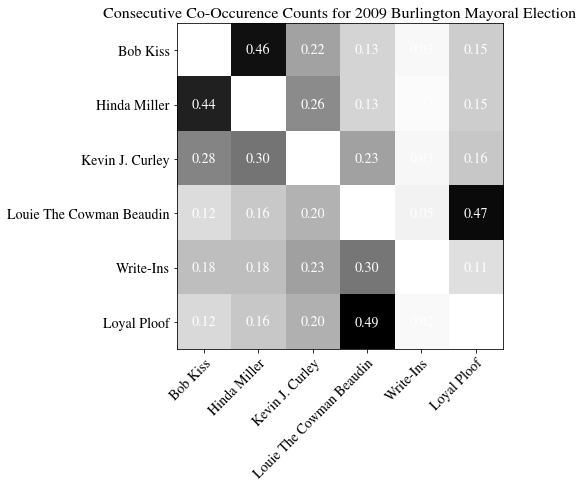

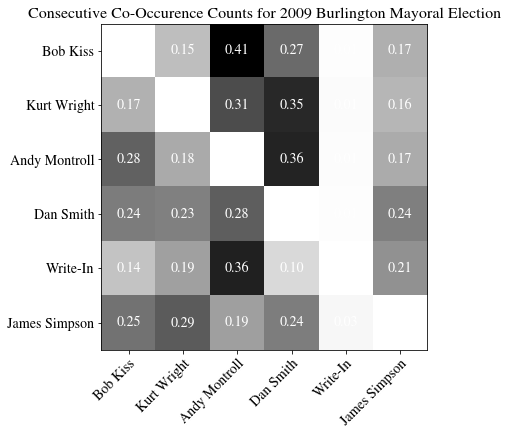

In [7]:
elections = utils.load_all_preflib_elections(f'../data/preflib/elections-all')
for collection, election_name, ballots, ballot_counts, cand_names, skipped_votes in elections:
    if collection != "burlington":
        continue
    # get elimination order
    k = len(cand_names)
    elim_votes = run_irv(k, ballots.copy(), ballot_counts, cands=cand_names.keys())
    sorted_cands = sorted(elim_votes, key=elim_votes.get, reverse=True)

    # get co-occurence matrix
    mtx = get_cooccurence_matrix(ballots, ballot_counts, sorted_cands)
    
    # plot co-occurence matrix
    cand_labels = [cand_names[cand] for cand in sorted_cands]
    
    plot_heatmap(mtx, row_labels=cand_labels, col_labels=cand_labels, title=f"Consecutive Co-Occurence Counts for 2009 Burlington Mayoral Election")

In [39]:
a = np.array([1, 2, 3, 4])
a[10:]

array([], dtype=int64)

## Limitations of the Contextual Model

In [3]:
from model import ContextModel

First Choice Prob
Bob Kiss: 0.2851685393258427
Andy Montroll: 0.23078651685393273
James Simpson: 0.0038202247191011234
Dan Smith: 0.1468539325842696
Kurt Wright: 0.3292134831460675
Write-In: 0.004157303370786518
Length Prob
1: 0.16573033707865167
2: 0.20584269662921348
3: 0.203370786516854
4: 0.10662921348314608
5: 0.31842696629213485
6: 0.0


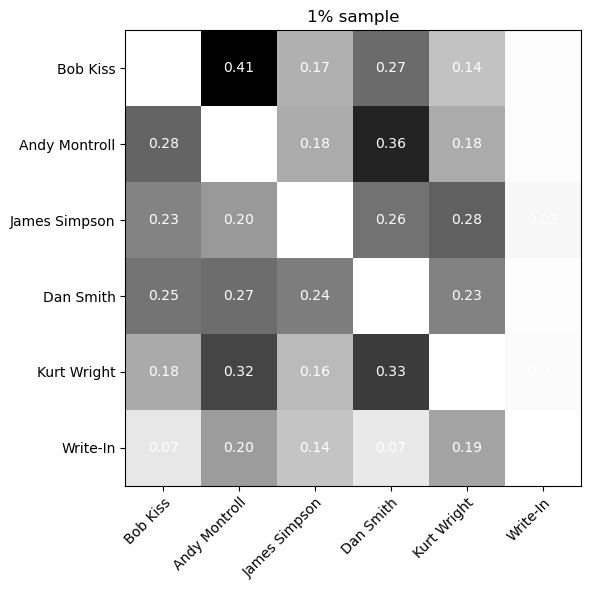

In [7]:
n_trials = 100

filename = "../data/preflib/elections-all/burlington/ED-00005-00000002.toi"

ballots, ballot_counts, cand_names, skipped_votes = \
    utils.read_preflib(filename)
cand_labels = [cand_names[cand] for cand in cand_names]

n = np.sum(ballot_counts)
k = len(cand_names)

### Params from 1% sample
sample_size = int(0.01 * n)

avg_first_choice_prob = np.zeros(k)
avg_lengths_prob = np.zeros(k + 1)
avg_transition_mtx = np.zeros((k, k))
for seed in range(n_trials):
    sample_counts = utils.resample(ballot_counts,
        sample_size=sample_size,
        with_replacement=False,
        seed=seed)

    ballot_model = ContextModel(cand_names=cand_names)
    ballot_model.fit(ballots.copy(), sample_counts)

    first_choice_prob, lengths_prob, transition_mtx = ballot_model.get_params()
    avg_first_choice_prob += first_choice_prob
    avg_lengths_prob += lengths_prob
    avg_transition_mtx += transition_mtx

avg_first_choice_prob /= n_trials
avg_lengths_prob /= n_trials
avg_transition_mtx /= n_trials

print("First Choice Prob")
for idx, prob in enumerate(avg_first_choice_prob):
    print(f"{cand_labels[idx]}: {prob}")

print("Length Prob")
for idx, prob in enumerate(avg_lengths_prob[1:]):
    print(f"{idx + 1}: {prob}")
    
plot_heatmap(avg_transition_mtx, row_labels=cand_labels, col_labels=cand_labels, title="1% sample")


First Choice Prob
Bob Kiss: 0.28805437931802985
Andy Montroll: 0.22977490528192557
James Simpson: 0.0039001560062402497
Dan Smith: 0.14553153554713616
Kurt Wright: 0.32872743481167815
Write-In: 0.004011589034989971
Length Prob
1: 0.16503231557833742
2: 0.21305995096946734
3: 0.200802317806998
4: 0.10318698462224203
5: 0.3179184310229552
6: 0.0


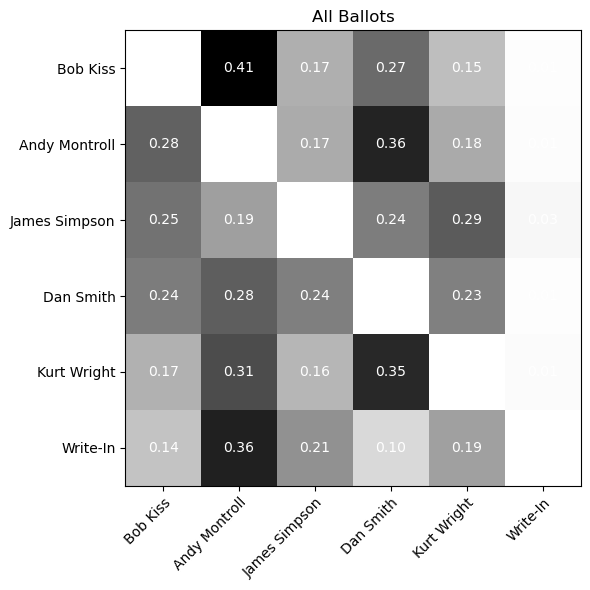

In [9]:
### Final params
ballot_model = ContextModel(cand_names=cand_names)
ballot_model.fit(ballots.copy(), ballot_counts)

first_choice_prob, lengths_prob, transition_mtx = ballot_model.get_params()

print("First Choice Prob")
for idx, prob in enumerate(first_choice_prob):
    print(f"{cand_labels[idx]}: {prob}")

print("Length Prob")
for idx, prob in enumerate(lengths_prob[1:]):
    print(f"{idx + 1}: {prob}")
    
plot_heatmap(transition_mtx, row_labels=cand_labels, col_labels=cand_labels, title="All Ballots")


In [13]:
simulated_ballots, simulated_counts = ballot_model.simulate_ballots(n)

print("Simulated")
for idx, ballot in enumerate(simulated_ballots[:25]):
    print(f"{ballot}: {simulated_counts[idx]}")

print("\n")

print("Actual")
for idx, ballot in enumerate(ballots[:25]):
    print(f"{ballot}: {ballot_counts[idx]}")

Simulated
[5]: 478
[1]: 414
[2]: 339
[5 4]: 223
[4]: 219
[1 2]: 217
[5 2]: 199
[2 4]: 167
[1 4]: 146
[2 1]: 133
[5 3]: 119
[1 2 4]: 118
[5 1]: 103
[1 3]: 95
[1 5]: 93
[2 5]: 89
[5 2 4]: 82
[4 2]: 82
[5 4 2]: 77
[1 2 4 3 5]: 75
[2 3]: 74
[4 1]: 73
[4 3]: 72
[5 4 2 1 3]: 71
[5 4 3]: 71


Actual
[5]: 840
[1 2]: 355
[1]: 326
[5 4]: 271
[5 2]: 256
[1 2 4]: 234
[2 1]: 200
[2]: 178
[5 2 4]: 147
[2 1 4]: 145
[2 4]: 139
[1 4]: 125
[4]: 124
[1 2 4 5 3]: 123
[5 4 2]: 122
[1 4 2]: 121
[1 2 4 3 5]: 120
[5 2 4 3 1]: 104
[1 2 3 4 5]: 103
[5 2 4 1 3]: 102
[5 4 2 1 3]: 101
[2 5]: 94
[4 5]: 93
[2 4 1]: 93
[5 4 2 3 1]: 90


In [16]:
# Which ballots are missed completely? 

from collections import Counter
ctr = Counter()
for ballot_idx, ballot in enumerate(ballots):
    ctr[tuple(ballot)] = ballot_counts[ballot_idx]

for ballot_idx, ballot in enumerate(simulated_ballots):
    if tuple(ballot) not in ctr:
        continue

    global_value = ctr[tuple(ballot)]
    # ctr[tuple(ballot)] = max(global_value - simulated_counts[ballot_idx], 0)
    ctr[tuple(ballot)] = 0

items = ctr.most_common()
for ballot, count in ctr.most_common():
    print(f"{np.array(ballot)} : {count}")


[4 1 2 6 3] : 5
[3 4 1 2 5] : 4
[1 6 2 4 3] : 4
[1 4 2 6 3] : 4
[4 2 1 6 3] : 3
[6 1] : 3
[4 2 6] : 3
[1 4 6] : 2
[4 1 3 2 6] : 2
[5 6 2 1] : 2
[1 3 2 6 4] : 2
[6 2 4 3 1] : 2
[6 2 4 1 3] : 2
[4 2 1 5 6] : 2
[2 6 1 4 3] : 2
[6 2 3 4 1] : 2
[4 2 1 6 5] : 2
[6 2 4] : 2
[4 1 6 2 3] : 2
[5 3 4 2 6] : 1
[1 6 5 3 4] : 1
[5 3 4 6 2] : 1
[2 6 4 1 3] : 1
[1 3 4 6] : 1
[2 1 6 5] : 1
[6 1 4 3 2] : 1
[2 3 5 6 1] : 1
[3 1 2 4] : 1
[6 1 5 2] : 1
[2 3 4 1 6] : 1
[3 1 2 4 5] : 1
[2 5 6] : 1
[3 6] : 1
[3 1 4 5] : 1
[3 1 4 2] : 1
[6 5 4 3 2] : 1
[3 2 5 1 6] : 1
[2 1 3 4 6] : 1
[6 1 2] : 1
[1 6 4 2 3] : 1
[3 5 1 4 2] : 1
[3 4 2] : 1
[3 4 1] : 1
[3 4 5] : 1
[1 3 6 2 5] : 1
[6 4 1 5 2] : 1
[4 3 2 6 1] : 1
[1 2 4 6] : 1
[2 5 6 3 1] : 1
[4 1 5 3 6] : 1
[5 6 4 2 3] : 1
[3 1 5 2 4] : 1
[3 2 5 4 1] : 1
[3 1 2 5 6] : 1
[1 3 4 6 5] : 1
[3 4 5 2 1] : 1
[2 1 6 5 3] : 1
[6 5 3 2 1] : 1
[1 3 2 5 6] : 1
[6 2 1 4 3] : 1
[5 2 6 4 1] : 1
[5 6 1] : 1
[2 5 4 6] : 1
[1 5 3 2 6] : 1
[6 2 1 5] : 1
[5] : 0
[1 2] : 0
[1] : 0
[5

First Choice Prob
Bob Kiss: 0.28805437931802985
Andy Montroll: 0.22977490528192557
James Simpson: 0.0039001560062402497
Dan Smith: 0.14553153554713616
Kurt Wright: 0.32872743481167815
Write-In: 0.004011589034989971
Length Prob
1: 0.16503231557833742
2: 0.21305995096946734
3: 0.200802317806998
4: 0.10318698462224203
5: 0.3179184310229552
6: 0.0


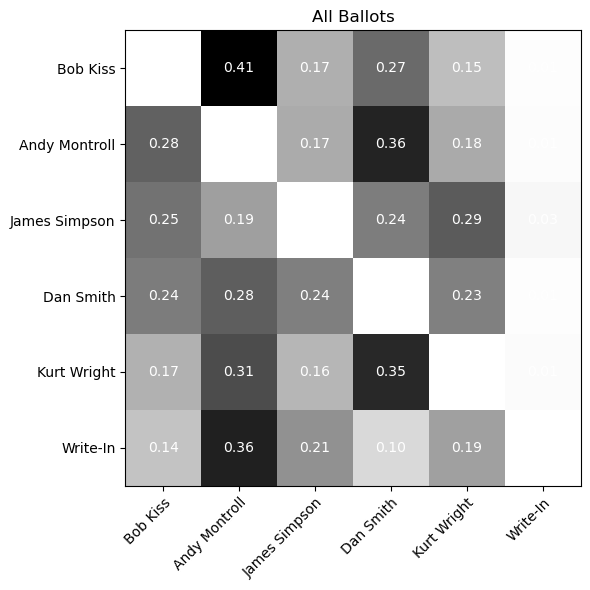

[[0.         0.40592956 0.16986179 0.2677218  0.14913063 0.00735622]
 [0.28034288 0.         0.17494643 0.35671147 0.17747906 0.01052016]
 [0.25459941 0.19109792 0.         0.23857567 0.28902077 0.02670623]
 [0.23962517 0.28491745 0.2356091  0.         0.23382419 0.0060241 ]
 [0.16727749 0.30942408 0.16125654 0.35052356 0.         0.01151832]
 [0.14       0.36       0.21       0.1        0.19       0.        ]]


In [26]:
### Variation in params by ballot length

ballot_model = ContextModel(cand_names=cand_names)

length = 7
filtered_ballots = []
filtered_counts = []
for idx, ballot in enumerate(ballots):
    if len(ballot) < length:
        filtered_ballots.append(ballot)
        filtered_counts.append(ballot_counts[idx])
        
ballot_model.fit(filtered_ballots.copy(), tuple(filtered_counts))

first_choice_prob, lengths_prob, transition_mtx = ballot_model.get_params()

print("First Choice Prob")
for idx, prob in enumerate(first_choice_prob):
    print(f"{cand_labels[idx]}: {prob}")

print("Length Prob")
for idx, prob in enumerate(lengths_prob[1:]):
    print(f"{idx + 1}: {prob}")
    
plot_heatmap(transition_mtx, row_labels=cand_labels, col_labels=cand_labels, title="All Ballots")
print(transition_mtx)